In [1]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install & Import Libraries
!pip install ultralytics -q

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import os
import time
import shutil
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from ultralytics import YOLO

print(" TensorFlow:", tf.__version__)
print(" GPU:", tf.config.list_physical_devices('GPU'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 TensorFlow: 2.20.0
 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Set Paths & Parameters

base = '/content/drive/MyDrive/advanced_banana_quality_project'

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

# Copy test data to local storage (faster)
print(" Copying test data to local storage...")
shutil.copytree(
    f'{base}/data/classification/test',
    '/content/test_data',
    dirs_exist_ok=True
)
print(" Test data copied!")
print(f"   Classes: {CLASS_NAMES}")

 Copying test data to local storage...
 Test data copied!
   Classes: ['overripe', 'ripe', 'rotten', 'unripe']


In [4]:
# Load All Classification Models

print(" Loading all models...")

# Custom CNN
custom_cnn = load_model(f'{base}/models/custom_cnn_model.keras')
print(" Custom CNN loaded!")

# MobileNetV2
mobilenet = load_model(f'{base}/models/mobilenetv2_model.keras')
print(" MobileNetV2 loaded!")

# EfficientNetB0
efficientnet = load_model(f'{base}/models/efficientnetb0_model.keras')
print(" EfficientNetB0 loaded!")

# ResNet50
resnet = load_model(f'{base}/models/resnet50_model.keras')
print(" ResNet50 loaded!")

print("\n All 4 classification models loaded!")

 Loading all models...
 Custom CNN loaded!
 MobileNetV2 loaded!
 EfficientNetB0 loaded!
 ResNet50 loaded!

 All 4 classification models loaded!


In [5]:
# Create Test Generators for Each Model

def make_test_generator(preprocess_fn):
    gen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    return gen.flow_from_directory(
        '/content/test_data',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

# Rescale for Custom CNN
rescale_gen = ImageDataGenerator(rescale=1./255)
test_gen_cnn = rescale_gen.flow_from_directory(
    '/content/test_data',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen_mn  = make_test_generator(mobilenet_preprocess)
test_gen_eff = make_test_generator(efficientnet_preprocess)
test_gen_res = make_test_generator(resnet_preprocess)

print(" All test generators ready!")
print(f"   Test samples: {test_gen_cnn.samples}")
print(f"   Class indices: {test_gen_cnn.class_indices}")

Found 562 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
 All test generators ready!
   Test samples: 562
   Class indices: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


In [6]:
# Evaluate All Models Function

def full_evaluate(model, model_name, test_gen):
    test_gen.reset()

    # Inference time
    start = time.time()
    predictions = model.predict(test_gen, verbose=0)
    end = time.time()

    inference_time = (end - start) / test_gen.samples * 1000
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())

    # Accuracy & Loss
    test_gen.reset()
    test_loss, test_accuracy = model.evaluate(test_gen, verbose=0)

    # Classification report
    report = classification_report(
        true_classes, predicted_classes,
        target_names=class_labels,
        output_dict=True
    )

    # Model size
    model_path = f'{base}/models/{model_name.lower().replace(" ","_")}_model.keras'
    model_size = os.path.getsize(model_path) / (1024*1024) if os.path.exists(model_path) else 0

    print(f"\n{'='*50}")
    print(f" {model_name}")
    print(f"{'='*50}")
    print(f"   Test Accuracy  : {test_accuracy*100:.2f}%")
    print(f"   Test Loss      : {test_loss:.4f}")
    print(f"   Inference Time : {inference_time:.2f} ms/image")
    print(f"   Model Size     : {model_size:.1f} MB")
    print(f"\n{classification_report(true_classes, predicted_classes, target_names=class_labels)}")

    return {
        'model': model_name,
        'test_accuracy': round(test_accuracy * 100, 2),
        'test_loss': round(test_loss, 4),
        'inference_time_ms': round(inference_time, 2),
        'model_size_mb': round(model_size, 1),
        'precision': round(report['weighted avg']['precision'], 4),
        'recall': round(report['weighted avg']['recall'], 4),
        'f1_score': round(report['weighted avg']['f1-score'], 4),
        'predictions': predictions,
        'predicted_classes': predicted_classes,
        'true_classes': true_classes,
        'class_labels': class_labels
    }

print(" Evaluation function ready!")

 Evaluation function ready!


In [7]:
# Run Evaluation on All Models

cnn_eval = full_evaluate(custom_cnn,  "Custom CNN",    test_gen_cnn)
mn_eval  = full_evaluate(mobilenet,   "MobileNetV2",   test_gen_mn)
eff_eval = full_evaluate(efficientnet,"EfficientNetB0", test_gen_eff)
res_eval = full_evaluate(resnet,      "ResNet50",       test_gen_res)

all_evals = [cnn_eval, mn_eval, eff_eval, res_eval]
print("\n All models evaluated!")


 Custom CNN
   Test Accuracy  : 97.51%
   Test Loss      : 0.0871
   Inference Time : 16.54 ms/image
   Model Size     : 302.3 MB

              precision    recall  f1-score   support

    overripe       0.93      0.98      0.96       113
        ripe       0.99      0.98      0.98       154
      rotten       0.99      0.96      0.97       185
      unripe       0.98      0.99      0.99       110

    accuracy                           0.98       562
   macro avg       0.97      0.98      0.97       562
weighted avg       0.98      0.98      0.98       562


 MobileNetV2
   Test Accuracy  : 97.51%
   Test Loss      : 0.0915
   Inference Time : 49.01 ms/image
   Model Size     : 13.4 MB

              precision    recall  f1-score   support

    overripe       0.95      0.98      0.97       113
        ripe       0.98      0.97      0.97       154
      rotten       0.98      0.97      0.98       185
      unripe       0.98      0.99      0.99       110

    accuracy                 

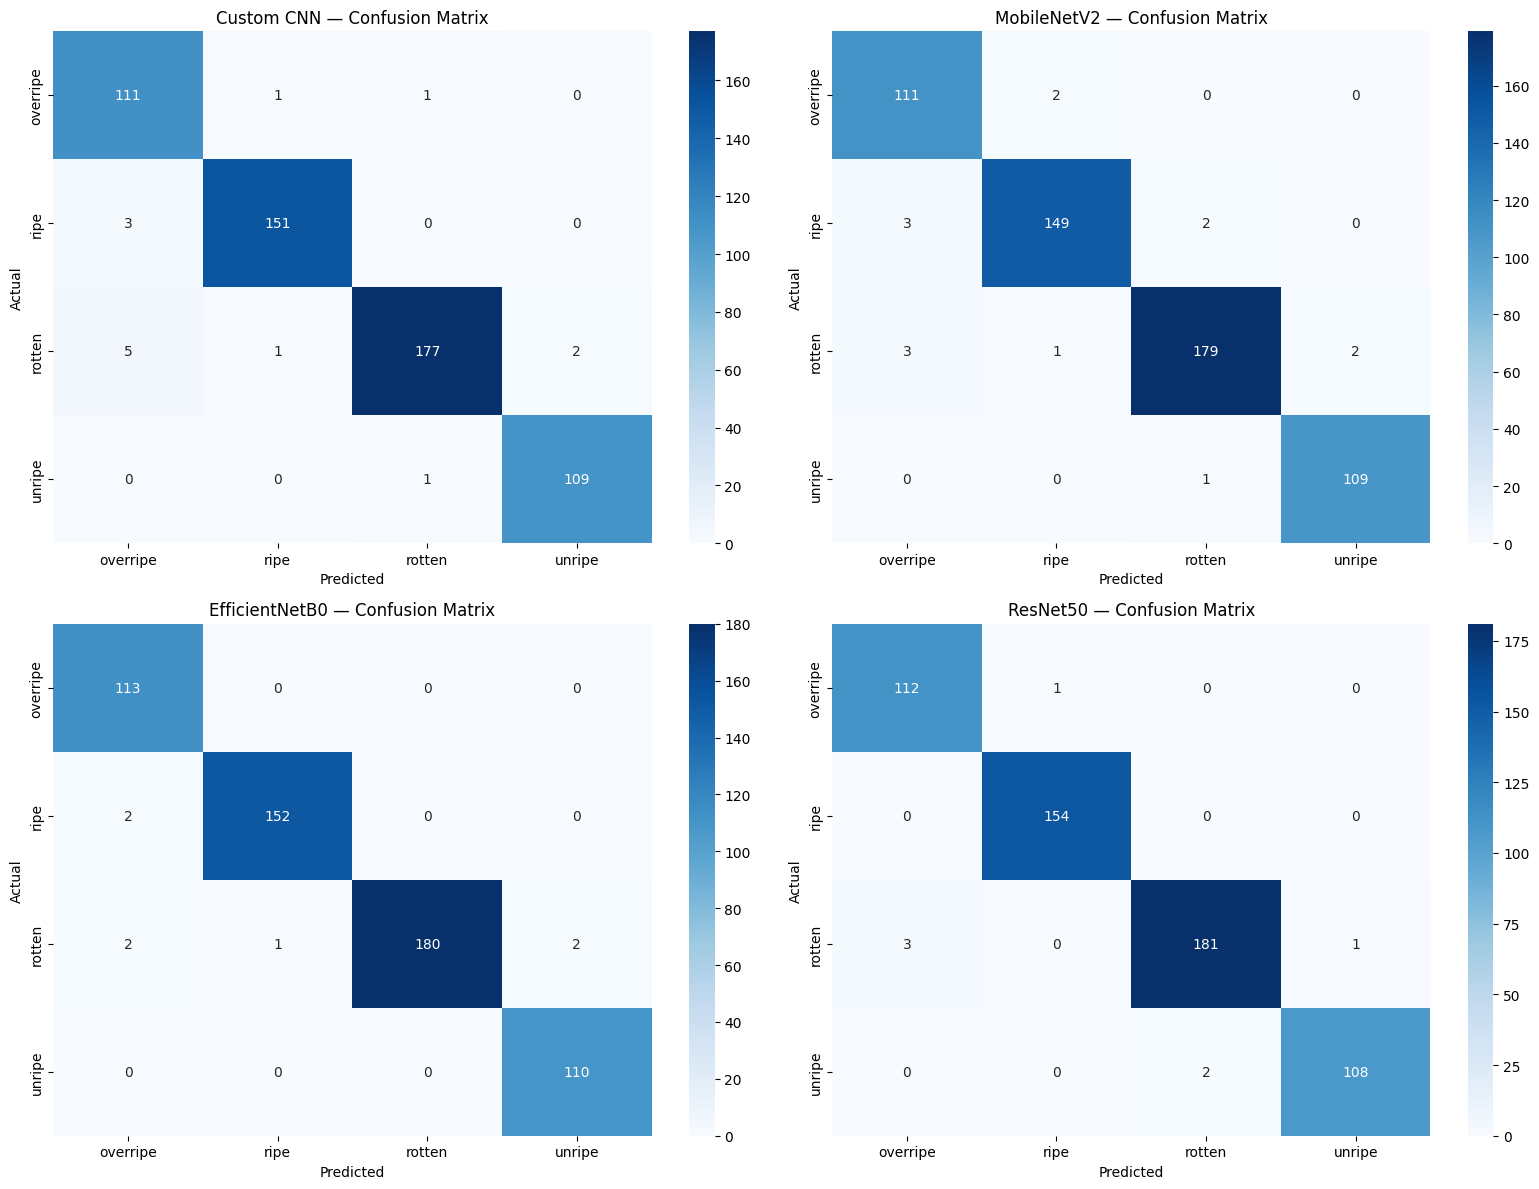

 All confusion matrices saved!


In [8]:
# Confusion Matrices (All 4 Models)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, eval_data in enumerate(all_evals):
    cm = confusion_matrix(
        eval_data['true_classes'],
        eval_data['predicted_classes']
    )
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=eval_data['class_labels'],
        yticklabels=eval_data['class_labels'],
        ax=axes[i]
    )
    axes[i].set_title(f"{eval_data['model']} — Confusion Matrix")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{base}/screenshots/all_confusion_matrices.png', dpi=150)
plt.show()
print(" All confusion matrices saved!")

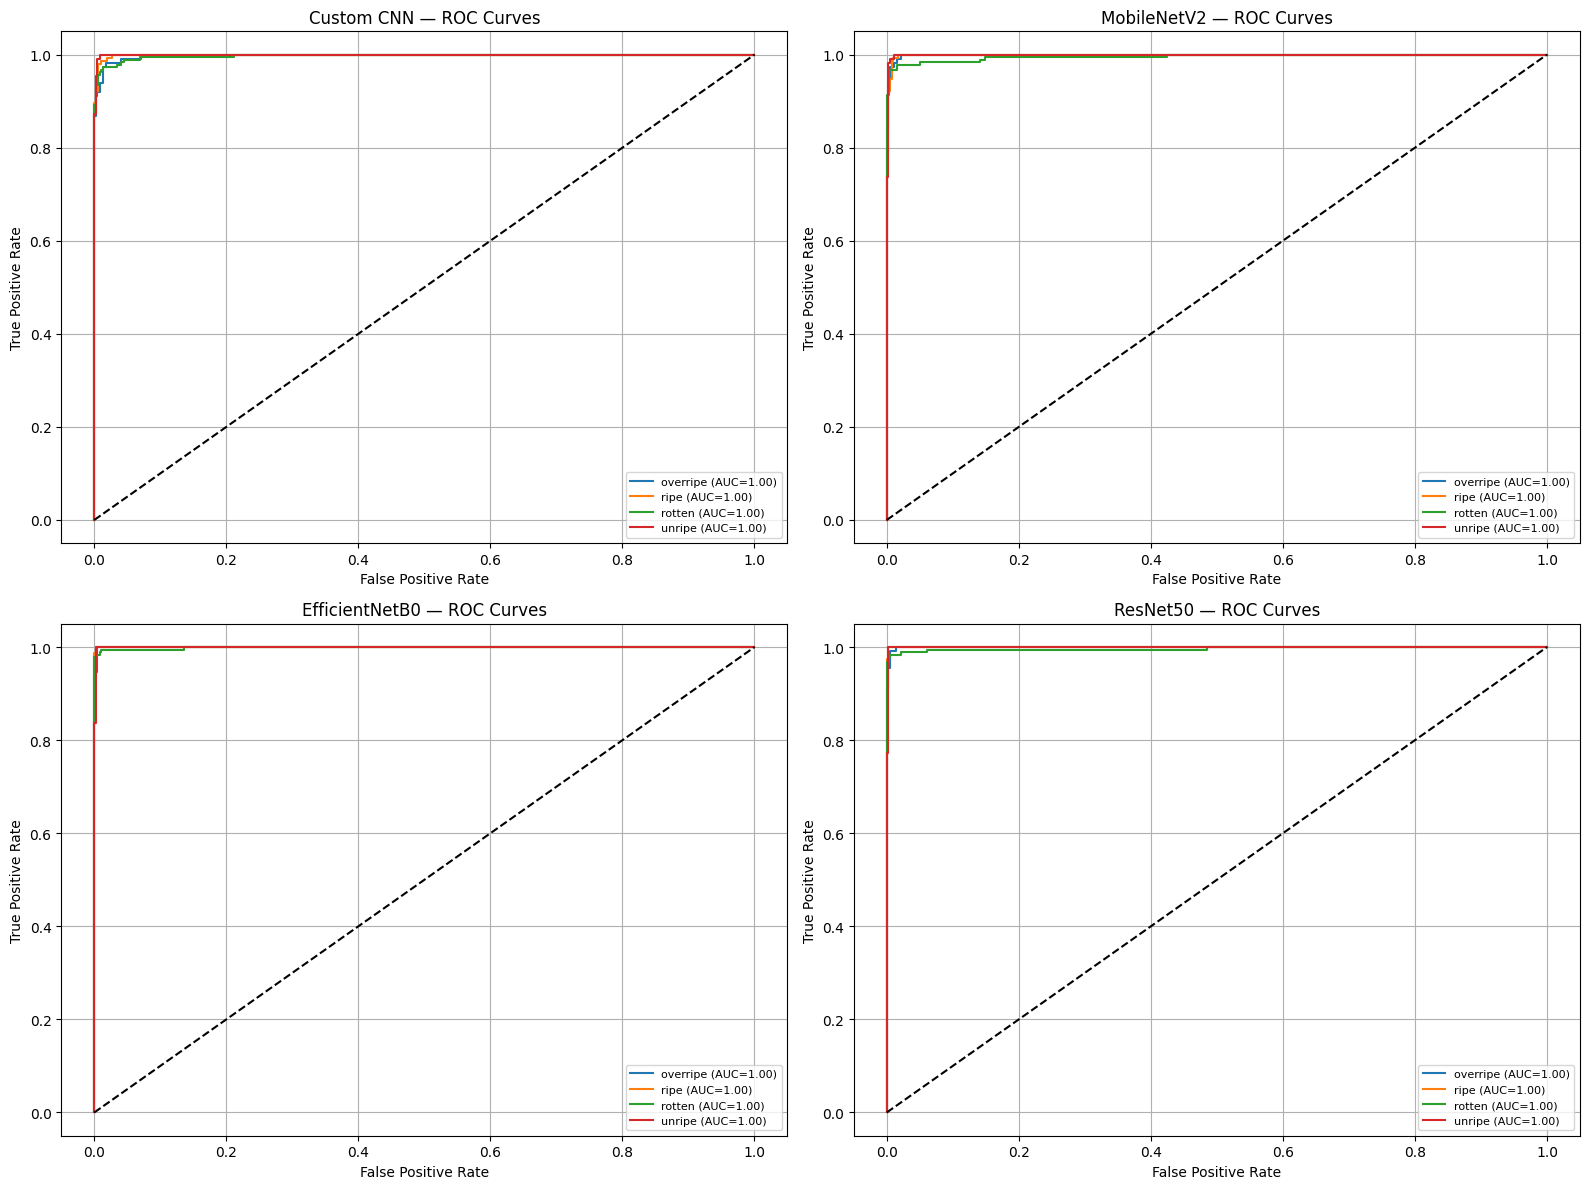

 ROC-AUC curves saved!


In [9]:
# ROC-AUC Curves (All 4 Models)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, eval_data in enumerate(all_evals):
    true_classes = eval_data['true_classes']
    predictions  = eval_data['predictions']
    class_labels = eval_data['class_labels']

    # One-hot encode true classes
    true_onehot = np.eye(NUM_CLASSES)[true_classes]

    # Plot ROC for each class
    for j, cls_name in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(true_onehot[:, j], predictions[:, j])
        roc_auc = auc(fpr, tpr)
        axes[i].plot(fpr, tpr, label=f'{cls_name} (AUC={roc_auc:.2f})')

    axes[i].plot([0,1], [0,1], 'k--')
    axes[i].set_title(f"{eval_data['model']} — ROC Curves")
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right', fontsize=8)
    axes[i].grid(True)

plt.tight_layout()
plt.savefig(f'{base}/screenshots/all_roc_curves.png', dpi=150)
plt.show()
print(" ROC-AUC curves saved!")

📊 EfficientNetB0 misclassified: 7 / 562 images


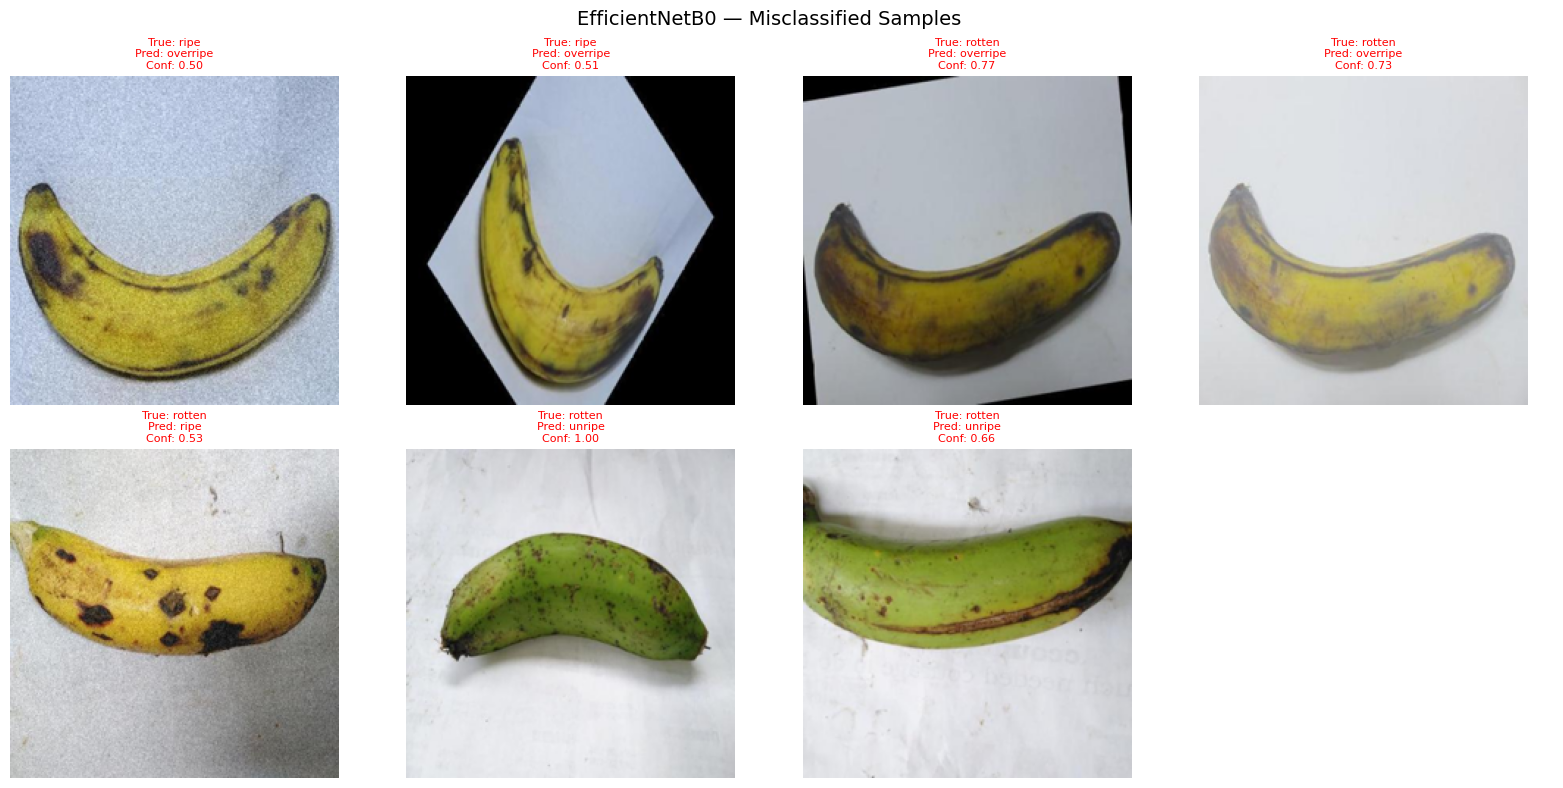

 Misclassified samples saved!


In [10]:
# Misclassified Sample Analysis

from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Find misclassified samples from best model (EfficientNetB0)
test_gen_eff.reset()
misclassified = []

for idx in range(len(eff_eval['true_classes'])):
    if eff_eval['predicted_classes'][idx] != eff_eval['true_classes'][idx]:
        misclassified.append({
            'idx': idx,
            'true': CLASS_NAMES[eff_eval['true_classes'][idx]],
            'pred': CLASS_NAMES[eff_eval['predicted_classes'][idx]],
            'confidence': float(np.max(eff_eval['predictions'][idx]))
        })

print(f"📊 EfficientNetB0 misclassified: {len(misclassified)} / {test_gen_eff.samples} images")

# Show up to 8 misclassified samples
samples_to_show = misclassified[:8]
file_paths = list(test_gen_eff.filenames)

for i, sample in enumerate(samples_to_show):
    img_path = f"/content/test_data/{file_paths[sample['idx']]}"
    img = Image.open(img_path).resize((224, 224))
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {sample['true']}\nPred: {sample['pred']}\nConf: {sample['confidence']:.2f}",
        fontsize=8, color='red'
    )
    axes[i].axis('off')

# Hide unused axes
for j in range(len(samples_to_show), 8):
    axes[j].axis('off')

plt.suptitle('EfficientNetB0 — Misclassified Samples', fontsize=14)
plt.tight_layout()
plt.savefig(f'{base}/screenshots/misclassified_samples.png', dpi=150)
plt.show()
print(" Misclassified samples saved!")

In [11]:
# Final Comparison Table + Charts

# Build comparison dataframe
comparison_data = []
for eval_data in all_evals:
    comparison_data.append({
        'Model': eval_data['model'],
        'Test Accuracy (%)': eval_data['test_accuracy'],
        'Test Loss': eval_data['test_loss'],
        'Precision': eval_data['precision'],
        'Recall': eval_data['recall'],
        'F1-Score': eval_data['f1_score'],
        'Inference Time (ms)': eval_data['inference_time_ms'],
        'Model Size (MB)': eval_data['model_size_mb']
    })

# Add YOLO results
with open(f'{base}/reports/yolo_detection_results.json', 'r') as f:
    yolo_data = json.load(f)

df = pd.DataFrame(comparison_data)
df = df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)
df.to_csv(f'{base}/reports/model_comparison.csv', index=False)

print(" Final Model Comparison Table:")
print(df.to_string(index=False))
print("\n Saved to reports/model_comparison.csv!")

 Final Model Comparison Table:
         Model  Test Accuracy (%)  Test Loss  Precision  Recall  F1-Score  Inference Time (ms)  Model Size (MB)
      ResNet50              98.75     0.0605     0.9876  0.9875    0.9875                25.46             97.1
EfficientNetB0              98.75     0.0370     0.9878  0.9875    0.9876                41.86             20.4
   MobileNetV2              97.51     0.0915     0.9753  0.9751    0.9751                49.01             13.4
    Custom CNN              97.51     0.0871     0.9757  0.9751    0.9752                16.54            302.3

 Saved to reports/model_comparison.csv!


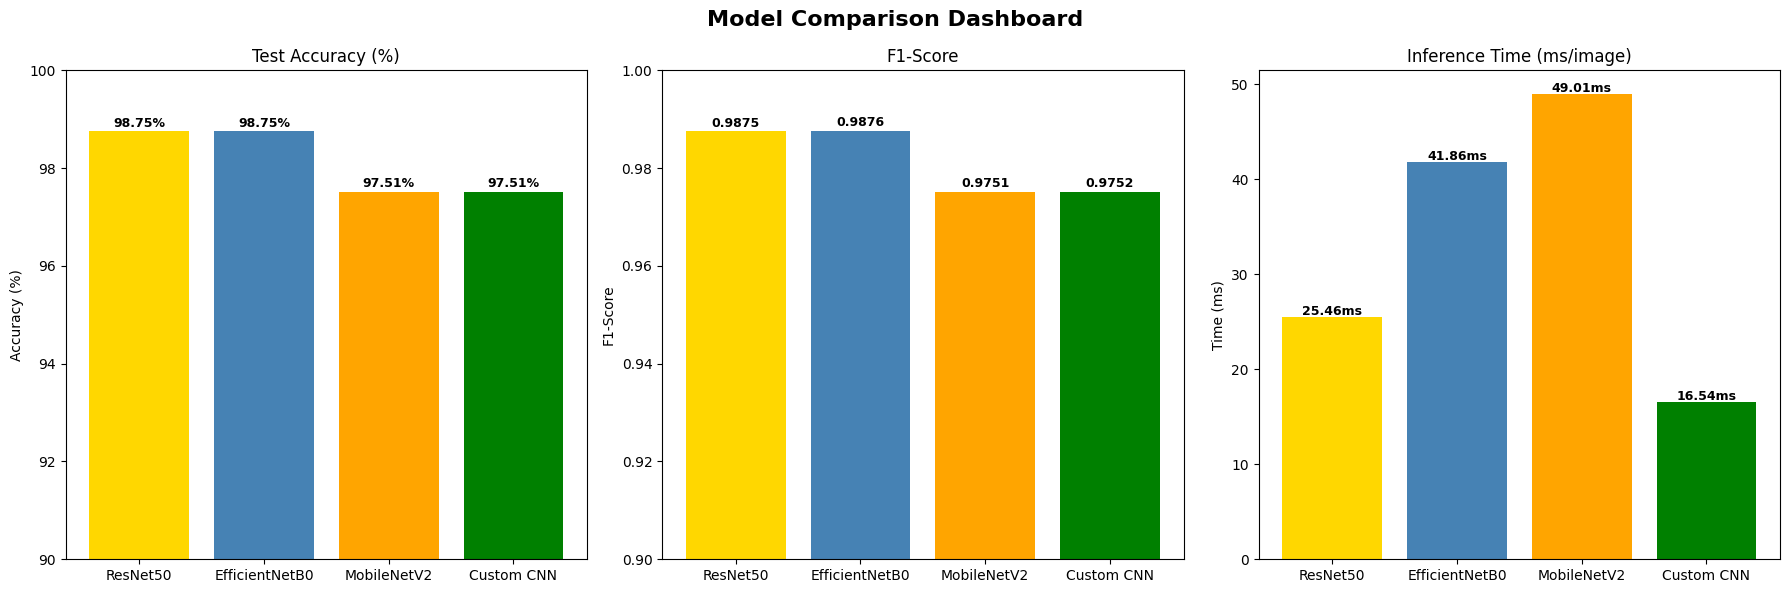

 Comparison dashboard saved!


In [12]:
# Comparison Bar Charts

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = df['Model'].tolist()
colors = ['gold', 'steelblue', 'orange', 'green']

# Accuracy
bars = axes[0].bar(models, df['Test Accuracy (%)'], color=colors)
axes[0].set_ylim(90, 100)
axes[0].set_title('Test Accuracy (%)')
axes[0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, df['Test Accuracy (%)']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val}%', ha='center', fontsize=9, fontweight='bold'
    )

# F1-Score
bars2 = axes[1].bar(models, df['F1-Score'], color=colors)
axes[1].set_ylim(0.90, 1.00)
axes[1].set_title('F1-Score')
axes[1].set_ylabel('F1-Score')
for bar, val in zip(bars2, df['F1-Score']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.4f}', ha='center', fontsize=9, fontweight='bold'
    )

# Inference Time
inf_times = [e for e in df['Inference Time (ms)']]
bars3 = axes[2].bar(models, inf_times, color=colors)
axes[2].set_title('Inference Time (ms/image)')
axes[2].set_ylabel('Time (ms)')
for bar, val in zip(bars3, inf_times):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{val}ms', ha='center', fontsize=9, fontweight='bold'
    )

plt.suptitle('Model Comparison Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{base}/screenshots/final_comparison_dashboard.png', dpi=150)
plt.show()
print(" Comparison dashboard saved!")

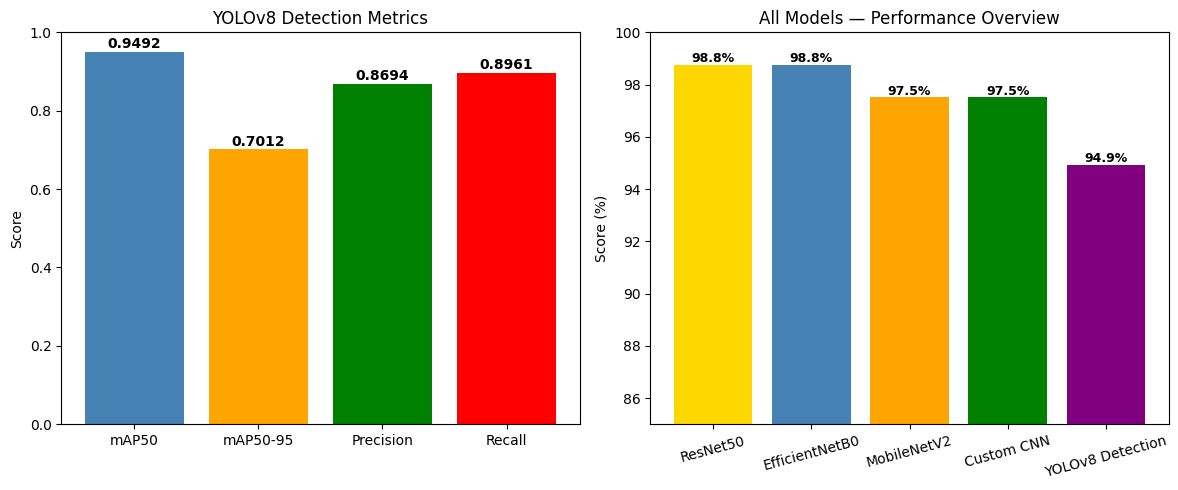

 YOLO summary chart saved!


In [13]:
#  YOLO Summary Chart

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# YOLO Metrics Bar
yolo_metrics = {
    'mAP50': yolo_data['mAP50'],
    'mAP50-95': yolo_data['mAP50_95'],
    'Precision': yolo_data['precision'],
    'Recall': yolo_data['recall']
}

bars = axes[0].bar(
    yolo_metrics.keys(),
    yolo_metrics.values(),
    color=['steelblue', 'orange', 'green', 'red']
)
axes[0].set_ylim(0, 1.0)
axes[0].set_title('YOLOv8 Detection Metrics')
axes[0].set_ylabel('Score')
for bar, val in zip(bars, yolo_metrics.values()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}', ha='center', fontsize=10, fontweight='bold'
    )

# Combined overview
all_model_names = df['Model'].tolist() + ['YOLOv8 Detection']
all_scores      = df['Test Accuracy (%)'].tolist() + [yolo_data['mAP50'] * 100]
all_colors      = ['gold', 'steelblue', 'orange', 'green', 'purple']

bars2 = axes[1].bar(all_model_names, all_scores, color=all_colors)
axes[1].set_ylim(85, 100)
axes[1].set_title('All Models — Performance Overview')
axes[1].set_ylabel('Score (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, all_scores):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(f'{base}/screenshots/yolo_summary_chart.png', dpi=150)
plt.show()
print(" YOLO summary chart saved!")

In [14]:
# Final Summary & Recommendation

print("=" * 60)
print(" FINAL PROJECT SUMMARY — BANANA QUALITY DETECTION")
print("=" * 60)

print("\n Classification Models:")
for _, row in df.iterrows():
    print(f"   {row['Model']:<20} Acc: {row['Test Accuracy (%)']:.2f}%  F1: {row['F1-Score']:.4f}  Speed: {row['Inference Time (ms)']}ms")

print(f"\n Detection Model (YOLOv8n):")
print(f"   {'YOLOv8 Detection':<20} mAP50: {yolo_data['mAP50']:.4f}  mAP50-95: {yolo_data['mAP50_95']:.4f}")

print("\n RECOMMENDATIONS:")
print("   Best Accuracy  → EfficientNetB0 & ResNet50 (98.75%)")
print("   Best Speed     → ResNet50 (fastest inference)")
print("   Best Detection → YOLOv8n (mAP50: 94.92%)")
print("   Best Overall   → EfficientNetB0 (highest accuracy + lowest loss)")

print("\n All Files Saved:")
screenshots = os.listdir(f'{base}/screenshots')
for s in sorted(screenshots):
    print(f"    screenshots/{s}")

reports = os.listdir(f'{base}/reports')
for r in sorted(reports):
    print(f"    reports/{r}")

print("\n NOTEBOOK 05 COMPLETE!")
print(" Next: Build Streamlit App!")

 FINAL PROJECT SUMMARY — BANANA QUALITY DETECTION

 Classification Models:
   ResNet50             Acc: 98.75%  F1: 0.9875  Speed: 25.46ms
   EfficientNetB0       Acc: 98.75%  F1: 0.9876  Speed: 41.86ms
   MobileNetV2          Acc: 97.51%  F1: 0.9751  Speed: 49.01ms
   Custom CNN           Acc: 97.51%  F1: 0.9752  Speed: 16.54ms

 Detection Model (YOLOv8n):
   YOLOv8 Detection     mAP50: 0.9492  mAP50-95: 0.7012

 RECOMMENDATIONS:
   Best Accuracy  → EfficientNetB0 & ResNet50 (98.75%)
   Best Speed     → ResNet50 (fastest inference)
   Best Detection → YOLOv8n (mAP50: 94.92%)
   Best Overall   → EfficientNetB0 (highest accuracy + lowest loss)

 All Files Saved:
    screenshots/EfficientNetB0_confusion_matrix.png
    screenshots/MobileNetV2_confusion_matrix.png
    screenshots/ResNet50_confusion_matrix.png
    screenshots/all_confusion_matrices.png
    screenshots/all_roc_curves.png
    screenshots/class_distribution.png
    screenshots/custom_cnn_confusion_matrix.png
    screenshots/cu